# GloFAS absolute values

Instead of probabilities (which will be used for monitoring)

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

from src.constants import *
from src.datasources import glofas

In [7]:
glofas.process_reforecast_ensembles(
    verbose=True, skip_lt_groups=["lt1104-1104"]
)

  0%|          | 0/189 [00:00<?, ?it/s]

Processing ndjamena_reforecast_ens_2009_lt504-600.grib
Processing ndjamena_reforecast_ens_2019_lt144-240.grib
Processing ndjamena_reforecast_ens_2023_lt864-960.grib
Processing ndjamena_reforecast_ens_2017_lt984-1080.grib
Processing ndjamena_reforecast_ens_2004_lt144-240.grib
Processing ndjamena_reforecast_ens_2011_lt144-240.grib
Processing ndjamena_reforecast_ens_2014_lt504-600.grib
Processing ndjamena_reforecast_ens_2022_lt264-360.grib
Processing ndjamena_reforecast_ens_2021_lt24-120.grib
Processing ndjamena_reforecast_ens_2018_lt24-120.grib
Processing ndjamena_reforecast_ens_2018_lt984-1080.grib
Processing ndjamena_reforecast_ens_2021_lt384-480.grib
Processing ndjamena_reforecast_ens_2020_lt624-720.grib
Processing ndjamena_reforecast_ens_2006_lt504-600.grib
Processing ndjamena_reforecast_ens_2013_lt504-600.grib
Processing ndjamena_reforecast_ens_2016_lt144-240.grib
Processing ndjamena_reforecast_ens_2003_lt144-240.grib
Processing ndjamena_reforecast_ens_2020_lt744-840.grib
Processing

In [8]:
ref_ens = glofas.load_reforecast_ensembles()

In [9]:
ref = (
    ref_ens.groupby(["time", "valid_time"])[["dis24", "leadtime"]]
    .mean()
    .reset_index()
)
ref["leadtime"] = ref["leadtime"].astype(int)

In [13]:
ref

,time,valid_time,dis24,leadtime
0,2003-06-01,2003-06-02,177.359375,1
1,2003-06-01,2003-06-03,175.403122,2
2,2003-06-01,2003-06-04,173.890625,3
3,2003-06-01,2003-06-05,173.784378,4
4,2003-06-01,2003-06-06,172.512497,5
...,...,...,...,...
70805,2023-11-25,2024-01-05,82.784378,41
70806,2023-11-25,2024-01-06,81.103127,42
70807,2023-11-25,2024-01-07,79.421875,43
70808,2023-11-25,2024-01-08,77.722656,44


In [14]:
ref.groupby("leadtime").size()

leadtime
1     1530
2     1530
3     1530
4     1530
5     1530
6     1553
7     1553
8     1553
9     1553
10    1553
11    1567
12    1567
13    1567
14    1567
15    1567
16    1567
17    1567
18    1567
19    1567
20    1567
21    1567
22    1567
23    1567
24    1567
25    1567
26    1586
27    1586
28    1586
29    1586
30    1586
31    1586
32    1586
33    1586
34    1586
35    1586
36    1601
37    1601
38    1601
39    1601
40    1601
41    1605
42    1605
43    1605
44    1605
45    1605
dtype: int64

In [15]:
max_complete_lt = 45
ref = ref[ref["leadtime"] <= max_complete_lt]

In [16]:
ref

,time,valid_time,dis24,leadtime
0,2003-06-01,2003-06-02,177.359375,1
1,2003-06-01,2003-06-03,175.403122,2
2,2003-06-01,2003-06-04,173.890625,3
3,2003-06-01,2003-06-05,173.784378,4
4,2003-06-01,2003-06-06,172.512497,5
...,...,...,...,...
70805,2023-11-25,2024-01-05,82.784378,41
70806,2023-11-25,2024-01-06,81.103127,42
70807,2023-11-25,2024-01-07,79.421875,43
70808,2023-11-25,2024-01-08,77.722656,44


In [ ]:
ref.groupby("leadtime")["dis24"]

In [34]:
rp_a = 5

rea = glofas.load_reanalysis()
rea = rea[rea["time"].dt.year.isin(ref["time"].dt.year.unique())]
rea_peaks = rea.loc[rea.groupby(rea["time"].dt.year)["dis24"].idxmax()]
q_rp_a = rea_peaks["dis24"].quantile(1 - 1 / rp_a)
rea_peaks["trigger"] = rea_peaks["dis24"] > q_rp_a
rea_peaks["year"] = rea_peaks["time"].dt.year
rea_peaks["cerf"] = rea_peaks["year"].isin(CERF_YEARS)
rea_peaks["rank"] = rea_peaks["dis24"].rank(ascending=False)
rea_peaks["rp"] = (len(rea_peaks) + 1) / rea_peaks["rank"]
rea_peaks.sort_values("rank")

,time,dis24,trigger,year,cerf,rank,rp
2819,2010-09-20,6714.9453,True,2010,False,1.0,22.000000
7208,2022-09-26,6254.0547,True,2022,True,2.0,11.000000
257,2003-09-15,6072.0000,True,2003,False,3.0,7.333333
3547,2012-09-17,5551.9844,True,2012,True,4.0,5.500000
1003,2005-09-30,4930.1953,False,2005,False,5.0,4.400000
6471,2020-09-19,3401.8203,False,2020,False,6.0,3.666667
5734,2018-09-13,3318.6250,False,2018,False,7.0,3.142857
1357,2006-09-19,3277.3750,False,2006,False,8.0,2.750000
1718,2007-09-15,3096.8672,False,2007,False,9.0,2.444444
6148,2019-11-01,2774.6250,False,2019,False,10.0,2.200000


In [42]:
rea

,time,dis24
0,2003-01-01,351.32812
1,2003-01-02,347.54688
2,2003-01-03,343.89062
3,2003-01-04,340.43750
4,2003-01-05,337.18750
...,...,...
7665,2023-12-27,96.18750
7666,2023-12-28,93.85156
7667,2023-12-29,91.66406
7668,2023-12-30,89.58594


In [40]:
rp_f = 5
lt_min = 0

val_col = "dis24"

dfs = []
dfs_threshs = []

for lt in ref["leadtime"].unique():
    # if lt < lt_min or lt >= 30:
    #     continue

    dff = ref[(ref["leadtime"] <= lt) & (ref["leadtime"] >= lt_min)]
    df_in = dff.loc[dff.groupby(dff["time"].dt.year)[val_col].idxmax()]
    df_in["lt_max"] = lt
    thresh = df_in[val_col].quantile(1 - 1 / rp_f)
    df_in["trigger"] = df_in[val_col] >= thresh
    # print(lt, thresh)
    dfs_threshs.append({"lt_max": lt, "thresh": thresh})
    dfs.append(df_in)

ref_threshs = pd.DataFrame(dfs_threshs)
ref_peaks = pd.concat(dfs, ignore_index=True)
ref_peaks["year"] = ref_peaks["time"].dt.year

In [41]:
ref_threshs

,lt_max,thresh
0,1,4841.825195
1,2,4863.952148
2,3,4932.335938
3,4,4932.335938
4,5,5009.368164
5,6,5167.268066
6,7,5245.661133
7,8,5250.716309
8,9,5250.716309
9,10,5250.716309


In [38]:
compare = rea_peaks.merge(ref_peaks, on="year", suffixes=["_a", "_f"])
for indicator in ["cerf", "trigger_a"]:
    compare[f"TP_{indicator}"] = compare[indicator] & compare["trigger_f"]
    compare[f"FP_{indicator}"] = ~compare[indicator] & compare["trigger_f"]
    compare[f"TN_{indicator}"] = ~compare[indicator] & ~compare["trigger_f"]
    compare[f"FN_{indicator}"] = compare[indicator] & ~compare["trigger_f"]

compare["days_error"] = (compare["time_a"] - compare["valid_time"]).dt.days
compare = compare.sort_values(["year", "lt_max"])

In [39]:
dicts = []
for lt, group in compare.groupby("lt_max"):
    TPR = group["TP_trigger_a"].sum() / group["trigger_a"].sum()
    PPV = group["TP_trigger_a"].sum() / group["trigger_f"].sum()
    TPR_C = group["TP_cerf"].sum() / group["cerf"].sum()
    PPV_C = group["TP_cerf"].sum() / group["trigger_f"].sum()
    dicts.append(
        {"TPR": TPR, "PPV": PPV, "TPR_C": TPR_C, "PPV_C": PPV_C, "lt_max": lt}
    )

metrics = pd.DataFrame(dicts)
metrics

,TPR,PPV,TPR_C,PPV_C,lt_max
0,1.00,0.8,1.0,0.4,1
1,1.00,0.8,1.0,0.4,2
2,1.00,0.8,1.0,0.4,3
3,1.00,0.8,1.0,0.4,4
4,1.00,0.8,1.0,0.4,5
5,1.00,0.8,1.0,0.4,6
6,1.00,0.8,1.0,0.4,7
7,1.00,0.8,1.0,0.4,8
8,1.00,0.8,1.0,0.4,9
9,1.00,0.8,1.0,0.4,10


Text(0.5, 1.0, "Fleuve Chari à N'Djamena\nPics annuels GloFAS (2003-2022),\npériode de retour 5 ans")

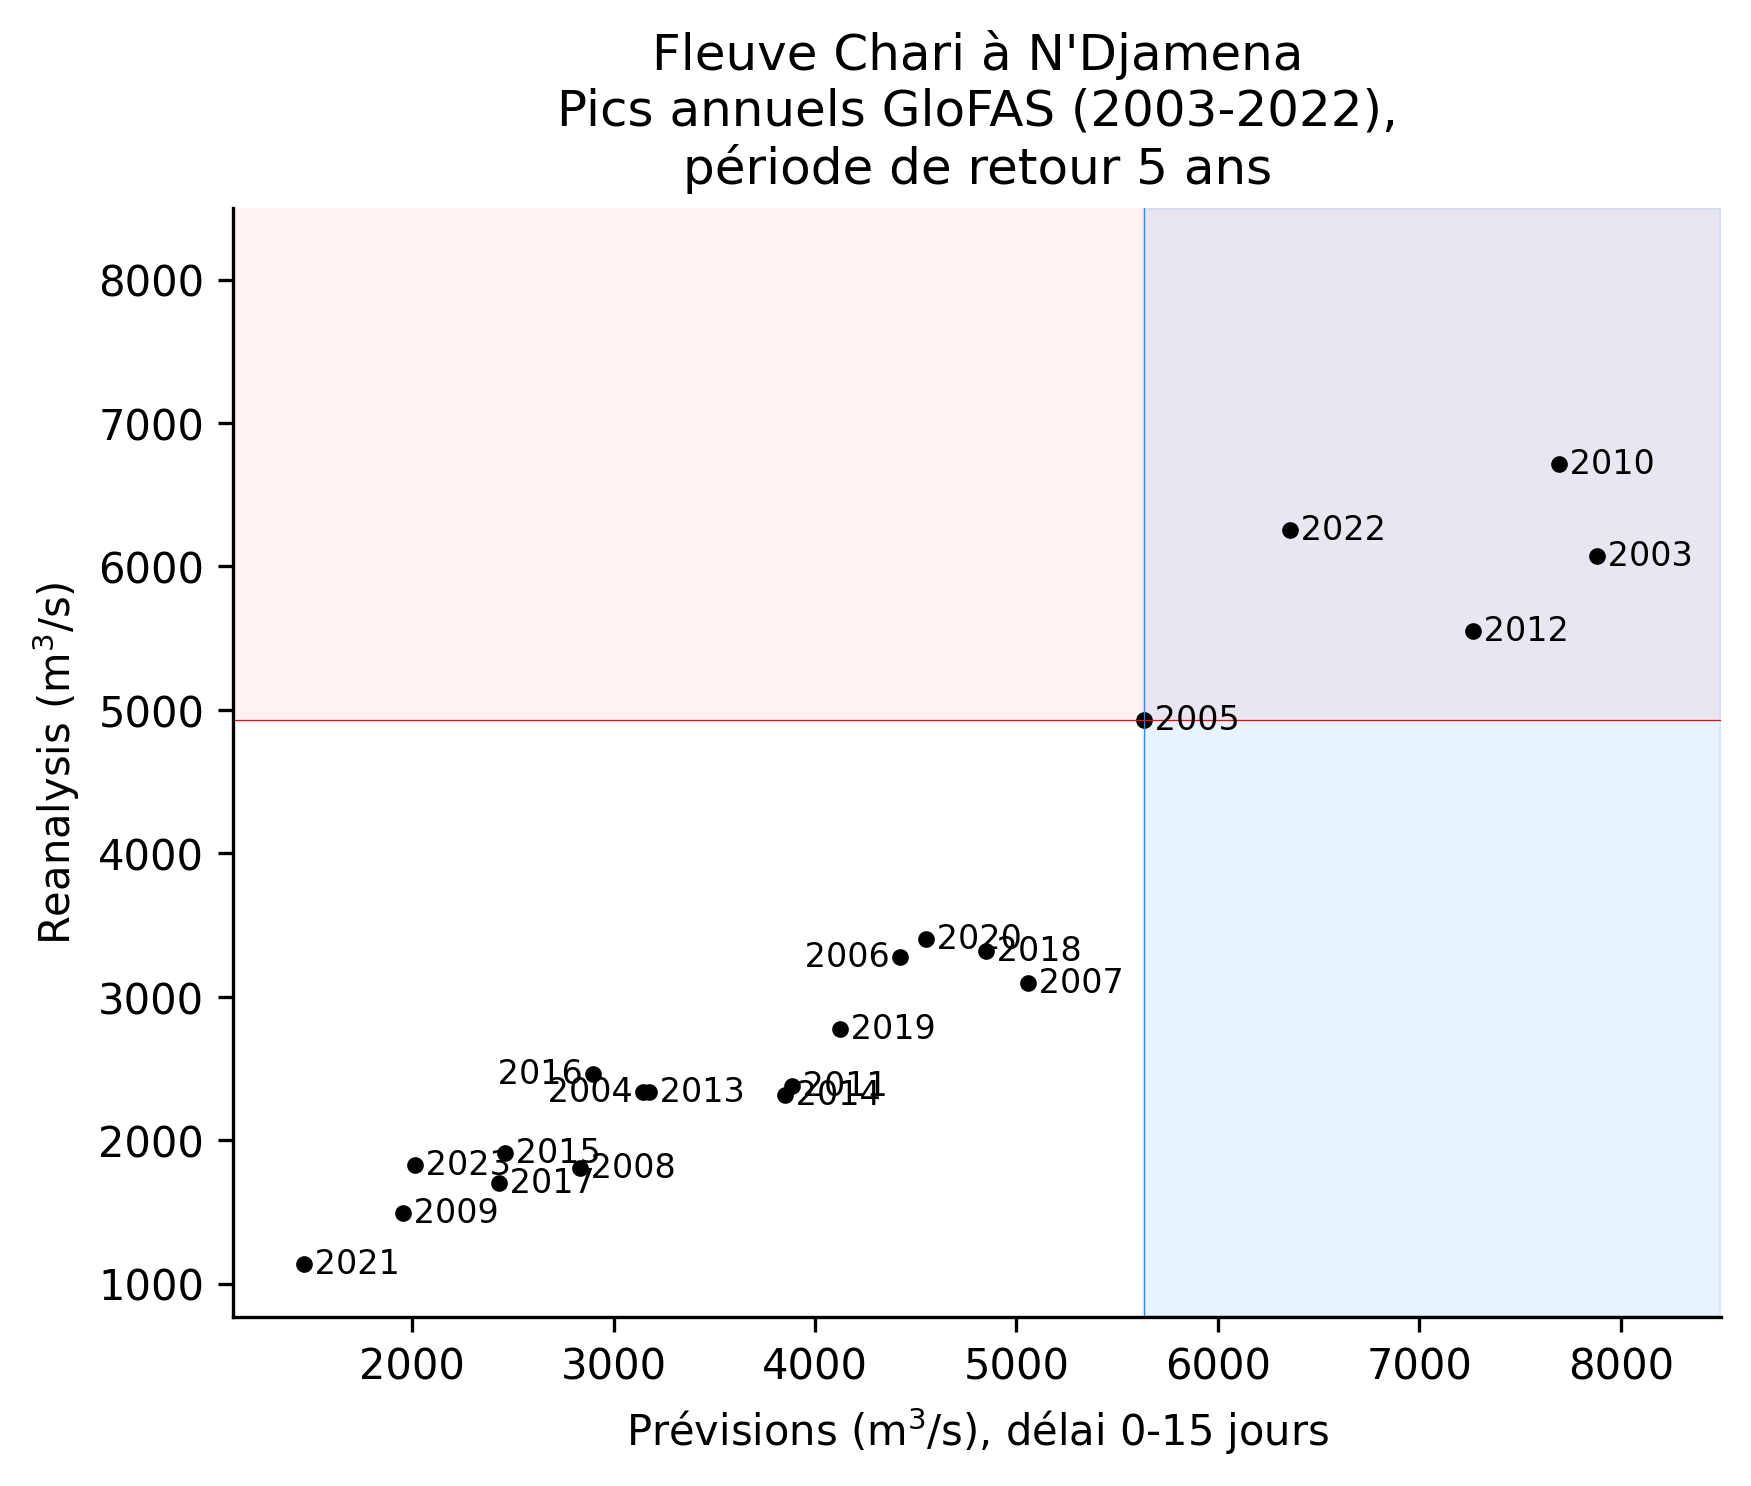

In [30]:
max_lt = 15

# 3yr
rp_a_3 = rea_peaks["dis24"].quantile(1 - 1 / 3)
rp_a_target = rea_peaks["dis24"].quantile(1 - 1 / rp_a)

rp_f = ref_threshs.set_index("lt_max").loc[max_lt, "thresh"]
compare_lt = compare[compare["lt_max"] == max_lt].copy()
fig, ax = plt.subplots(dpi=300)
compare_lt.plot(
    y="dis24_a",
    x="dis24_f",
    ax=ax,
    marker=".",
    color="k",
    linestyle="",
    legend=False,
)

ax.axvline(x=rp_f, color="dodgerblue", linestyle="-", linewidth=0.3)
ax.axvspan(
    rp_f,
    8500,
    ymin=0,
    ymax=1,
    color="dodgerblue",
    alpha=0.1,
)
if rp_a <= 3:
    ax.axhline(y=rp_a_3, color="red", linestyle="-", linewidth=0.3)
    ax.axhspan(
        rp_a_3,
        8500,
        color="red",
        alpha=0.05,
        linestyle="None",
    )

ax.axhline(y=rp_a_target, color="red", linestyle="-", linewidth=0.3)
ax.axhspan(
    rp_a_target,
    8500,
    color="red",
    alpha=0.05,
    linestyle="None",
)

for year, row in compare_lt.set_index("year").iterrows():
    flip_years = [2004, 2006, 0, 2016]
    ha = "right" if year in flip_years else "left"
    ax.annotate(
        f" {year} ",
        (row["dis24_f"], row["dis24_a"]),
        color="k",
        fontsize=8,
        va="center",
        ha=ha,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Reanalysis (m$^3$/s)")
ax.set_xlabel(f"Prévisions (m$^3$/s), délai {lt_min}-{max_lt} jours")
ax.set_ylim(top=8500)
ax.set_xlim(right=8500)
ax.set_title(
    f"Fleuve Chari à N'Djamena\nPics annuels GloFAS (2003-2022),\n"
    f"période de retour {rp_a} ans"
)

Text(0.5, 0, 'Observational yearly peak (cm)')

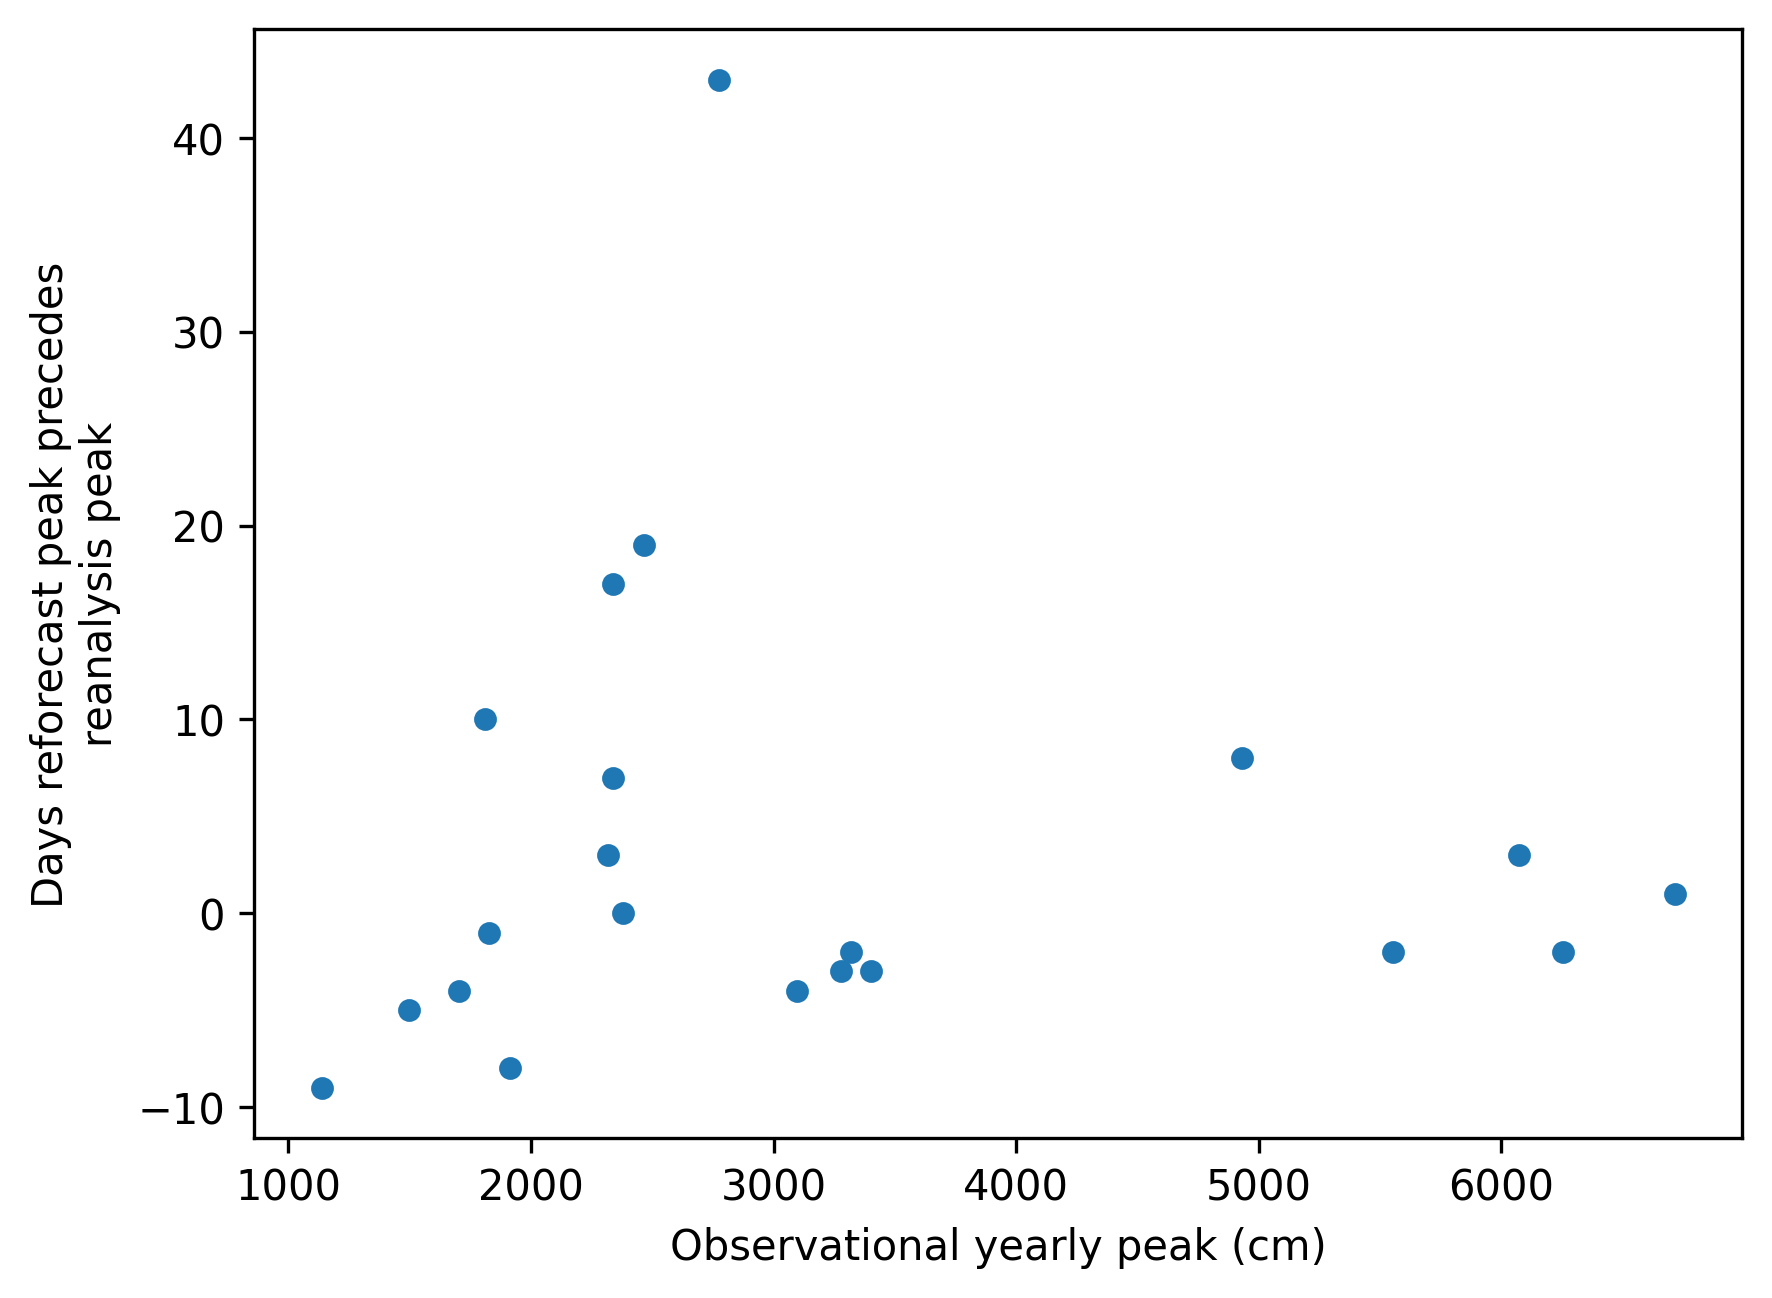

In [31]:
fig, ax = plt.subplots(dpi=300)
compare_lt.plot.scatter(x="dis24_a", y="days_error", ax=ax)
ax.set_ylabel("Days reforecast peak precedes\nreanalysis peak")
ax.set_xlabel("Observational yearly peak (cm)")

In [32]:
ref_peaks[ref_peaks["lt_max"] == max_lt]

,time,valid_time,dis24,leadtime,lt_max,trigger,year
294,2003-08-28,2003-09-12,7882.218750,15,15,True,2003
295,2004-08-17,2004-09-01,3147.306152,15,15,False,2004
296,2005-09-07,2005-09-22,5634.702148,15,15,True,2005
297,2006-09-07,2006-09-22,4421.937500,15,15,False,2006
298,2007-09-04,2007-09-19,5055.772461,15,15,False,2007
299,2008-09-04,2008-09-19,2831.868652,15,15,False,2008
300,2009-08-31,2009-09-15,1954.646118,15,15,False,2009
301,2010-09-04,2010-09-19,7695.441406,15,15,True,2010
302,2011-09-11,2011-09-26,3884.681152,15,15,False,2011
303,2012-09-04,2012-09-19,7267.866211,15,15,True,2012
